In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import numpy as np
import torch
import torch.nn as nn
# matplotlib.use('Agg')  # Headless plotting
import matplotlib.pyplot as plt
from timeit import default_timer
from darcy.config import *  # expects device, seed
from darcy.parameter import *
from darcy.afpinns import AFPINN
from tqdm import tqdm
import numpy as np
seed = 121
torch.manual_seed(seed)
np.random.seed(seed)

AcceleratorError: CUDA error: invalid device ordinal
GPU device may be out of range, do you have enough GPUs?
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [18]:
# load data 
data_test = np.load("data/test_dataset_out.npz", allow_pickle=True)
k = torch.tensor(data_test["k"], dtype=torch.float32)
f = torch.tensor(data_test["f"], dtype=torch.float32)
p_exact = torch.tensor(data_test["p"], dtype=torch.float32)
perm_params = data_test["perm_params"]
forcing_params = data_test["forcing_params"]

dataset = np.load("data/darcy_pred_fno_out.npz", allow_pickle=True)
p_fno_pred = torch.tensor(dataset["predictions"], device=device)

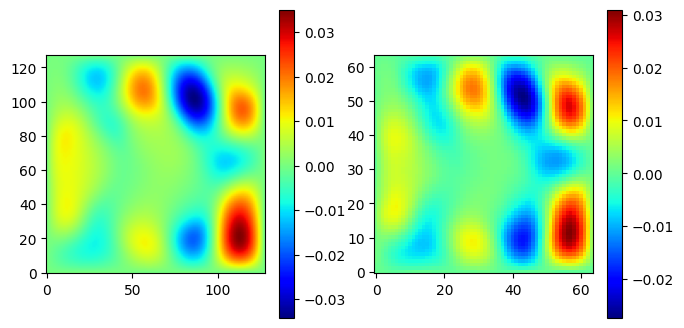

In [19]:
i = 7
plt.figure(figsize=(12,4))
plt.subplot(1,3,2)
plt.imshow(p_exact[i,:,:].cpu().numpy(), origin='lower', cmap='jet')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(p_fno_pred[i,:,:].cpu().numpy(), origin='lower', cmap='jet')
plt.colorbar()

In [20]:
# mode
N = n_fno
K = 200
x_min, x_max = float(x_fno.min().item()), float(x_fno.max().item())
y_min, y_max = float(y_fno.min().item()), float(y_fno.max().item())
Lx = (x_max - x_min)
Ly = (y_max - y_min)

In [21]:
chunk_size = 256
Err = []
def train_afpinn_for_fno(i):
    u_grid = p_fno_pred[i].cpu().numpy()  # shape (N, N)
    U_fft  = np.fft.fft2(u_grid)
    amplitudes = np.abs(U_fft)
    top_k_flat = np.argpartition(amplitudes.ravel(), -K)[-K:]
    top_k_idx = np.array(np.unravel_index(top_k_flat, (N,N))).T
    order = np.argsort(-amplitudes[top_k_idx[:,0], top_k_idx[:,1]])
    top_k_idx = top_k_idx[order]

    ix_sel = top_k_idx[:,0]
    it_sel = top_k_idx[:,1]
    C_sel  = U_fft[ix_sel, it_sel]


    ix_signed = np.fft.fftfreq(N) * N
    it_signed = np.fft.fftfreq(N) * N

    ix_s = ix_signed[ix_sel]
    it_s = it_signed[it_sel]

    kx_sel  = 2 * np.pi   * ix_s / Lx
    kt_sel  = 2 * np.pi * it_s / Ly
    phi_sel = -kx_sel * x_min - kt_sel * y_min + np.angle(C_sel)
    amp_sel = np.abs(C_sel) / (N**2)    


    mask = ~((ix_sel==0) & (it_sel==0))
    kx = kx_sel[mask].astype(np.float32)
    kt = kt_sel[mask].astype(np.float32)
    phi = phi_sel[mask].astype(np.float32)
    amp = amp_sel[mask].astype(np.float32)
    K_eff = int(mask.sum())

    u_cosine_sum = sum(
        amp[k] * torch.cos(kx[k]*x_fno.reshape(n_fno,n_fno) + kt[k]*y_fno.reshape(n_fno,n_fno) + phi[k])
        for k in range(K_eff)
    )
    bias_init = float(np.mean(u_grid - u_cosine_sum.cpu().numpy()))
    u_recon   = u_cosine_sum + bias_init

    err_numpy = np.linalg.norm(u_recon.cpu() - u_grid) / np.linalg.norm(u_grid)
    print(f"K_eff={K_eff}, bias={bias_init:.6f}")
    print(f"Numpy physical reconstruction rel-L2: {err_numpy:.4e}")

    kx, kt,phi, coeff = torch.tensor(kx), torch.tensor(kt), torch.tensor(phi), torch.tensor(amp)
    AFPINN_model = AFPINN(kx, kt, phi, coeff, bias = bias_init).to(device)

    optimizer_AFPINN = torch.optim.LBFGS(AFPINN_model.parameters(), 
                                lr=1.0,                            
                                max_iter=5000,
                                max_eval=10**10,
                                tolerance_grad=1e-10,
                                tolerance_change=1e-10,
                                history_size=50,
                                line_search_fn=None)




    x_interior = x_collocation.clone()
    y_interior = y_collocation.clone()
    k_p, dk_dx_p, dk_dy_p = permeability_derivatives(x_interior, y_interior, perm_params[i], device=device)
    rhs = forcing_function(x_interior, y_interior, forcing_params[i])
    u_bc_left = torch.zeros_like(y_bc)
    u_bc_right = torch.zeros_like(y_bc)
    u_bc_bottom = torch.zeros_like(x_bc)
    u_bc_top = torch.zeros_like(x_bc)
    exact = p_exact[i] 



    def afpinn_loss():   

        u, u_x, u_y, u_xx, u_yy = AFPINN_model(x_interior, y_interior)
        # print(u.shape, u_x.shape, u_y.shape, u_xx.shape, u_yy.shape, k_p1.shape, kx_p1.shape, ky_p1.shape, rhs.shape)

        pde_loss = (torch.mean((- (k_p * (u_yy + u_xx) + dk_dx_p * u_x + dk_dy_p * u_y) - rhs)**2))
        
        u_pred_bc_left, _, _, _, _ = AFPINN_model(x_bc_left, y_bc)
        u_pred_bc_right, _, _, _, _ = AFPINN_model(x_bc_right, y_bc)
        u_pred_bc_bottom, _, _, _, _ = AFPINN_model(x_bc, y_bc_bottom)
        u_pred_bc_top, _, _, _, _ = AFPINN_model(x_bc, y_bc_top)

        
        bc_loss = torch.mean((u_pred_bc_left - u_bc_left) ** 2) +\
                torch.mean((u_pred_bc_right - u_bc_right) ** 2) +\
                torch.mean((u_pred_bc_bottom - u_bc_bottom) ** 2) + \
                torch.mean((u_pred_bc_top - u_bc_top) ** 2)
        
        # Total loss with optional weighting
        total_loss = pde_loss + 500 * bc_loss
        return total_loss, pde_loss, bc_loss

    def train_afpinn(optimizer):

        global itr
        itr = 0

        def closure():
            global itr
            optimizer.zero_grad()
            total_loss, pde_loss, bc_loss = afpinn_loss()

            total_loss.backward()

            if itr % 1000 == 0 or itr == 100:
                with torch.no_grad():

                    numerical, _, _, _, _ = AFPINN_model(x_test.to(device), y_test.to(device))
                    # print(numerical.shape, exact.shape)
                    errL2 = (torch.sum(torch.abs(exact.reshape(-1).to(device)-numerical)**2))**0.5 / (torch.sum(torch.abs(exact.reshape(-1).to(device))**2))**0.5
                    errMax = torch.max(torch.abs(exact.reshape(-1).to(device)-numerical))

                print(f'Epoch[{itr}]  '
                        f'Total Loss: {total_loss.item():.6f}, '
                        f'PDE Loss: {pde_loss.item():.6f}, '
                        f'BC Loss: {bc_loss.item():.6f}\n\t\t'
                        f'RelativeL2: {errL2},\t'
                        f'Max: {errMax}\n' )
                
                torch.cuda.empty_cache()

                

            
            itr += 1

            return total_loss

        loss = optimizer.step(closure)

    loss = train_afpinn(optimizer_AFPINN)
    with torch.no_grad():
        numerical, _, _, _, _ = AFPINN_model(x_test.to(device), y_test.to(device))
    torch.cuda.empty_cache()
    return numerical.cpu(), exact.cpu()


In [22]:
for i in tqdm(range(0,10)):
    numerical, exact = train_afpinn_for_fno(i)
    ErrL2 = (torch.sum(torch.abs(exact.reshape(-1)-numerical.reshape(-1))**2))**0.5 / (torch.sum(torch.abs(exact.reshape(-1))**2))**0.5
    ErrMax = torch.max(torch.abs(exact.reshape(-1)-numerical.reshape(-1)))
    print(f'Test Relative L2 Error: {ErrL2.item()}, Test Max Error: {ErrMax.item()}')
    Err.append((i, ErrL2.item(), ErrMax.item()))

  0%|          | 0/10 [00:00<?, ?it/s]C:\Users\rklab\AppData\Local\Temp\ipykernel_47816\3312108214.py:43: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  err_numpy = np.linalg.norm(u_recon.cpu() - u_grid) / np.linalg.norm(u_grid)


K_eff=199, bias=-0.000302
Numpy physical reconstruction rel-L2: 1.1058e-01
Epoch[0]  Total Loss: 19.014597, PDE Loss: 19.010399, BC Loss: 0.000008
		RelativeL2: 0.19988273084163666,	Max: 0.008823160082101822

Epoch[100]  Total Loss: 1.772189, PDE Loss: 1.746994, BC Loss: 0.000050
		RelativeL2: 0.2203436642885208,	Max: 0.010060351341962814



 10%|█         | 1/10 [00:06<00:59,  6.60s/it]

Test Relative L2 Error: 0.21682628989219666, Test Max Error: 0.012745600193738937
K_eff=199, bias=-0.001305
Numpy physical reconstruction rel-L2: 1.1276e-01
Epoch[0]  Total Loss: 75.542526, PDE Loss: 75.522682, BC Loss: 0.000040
		RelativeL2: 0.27590546011924744,	Max: 0.02337874472141266

Epoch[100]  Total Loss: 6.711768, PDE Loss: 6.592711, BC Loss: 0.000238
		RelativeL2: 0.2937639653682709,	Max: 0.02258577197790146

Epoch[1000]  Total Loss: 5.635653, PDE Loss: 5.476884, BC Loss: 0.000318
		RelativeL2: 0.1911579817533493,	Max: 0.022243473678827286

Epoch[2000]  Total Loss: 5.405841, PDE Loss: 5.286492, BC Loss: 0.000239
		RelativeL2: 0.31673288345336914,	Max: 0.02132570743560791

Epoch[3000]  Total Loss: 5.027112, PDE Loss: 4.884512, BC Loss: 0.000285
		RelativeL2: 0.2223861813545227,	Max: 0.021759260445833206



 20%|██        | 2/10 [00:47<03:32, 26.55s/it]

...

Test Relative L2 Error: 0.8238300085067749, Test Max Error: 0.023493412882089615
K_eff=199, bias=0.003115
Numpy physical reconstruction rel-L2: 1.1209e-01
Epoch[0]  Total Loss: 73.392044, PDE Loss: 73.383514, BC Loss: 0.000017
		RelativeL2: 0.2308240532875061,	Max: 0.023722894489765167

Epoch[100]  Total Loss: 6.608084, PDE Loss: 6.378684, BC Loss: 0.000459
		RelativeL2: 0.28410202264785767,	Max: 0.023760072886943817

Epoch[1000]  Total Loss: 5.224412, PDE Loss: 4.829094, BC Loss: 0.000791
		RelativeL2: 0.3007938861846924,	Max: 0.0270881038159132

Epoch[2000]  Total Loss: 4.416250, PDE Loss: 3.695926, BC Loss: 0.001441
		RelativeL2: 0.38419270515441895,	Max: 0.03876114636659622



 90%|█████████ | 9/10 [04:10<00:31, 31.12s/it]

Test Relative L2 Error: 0.36540982127189636, Test Max Error: 0.0373728908598423
K_eff=199, bias=-0.032592
Numpy physical reconstruction rel-L2: 5.1830e-02
Epoch[0]  Total Loss: 144.620911, PDE Loss: 144.588379, BC Loss: 0.000065
		RelativeL2: 0.26208412647247314,	Max: 0.03924185037612915

Epoch[100]  Total Loss: 9.451822, PDE Loss: 9.151115, BC Loss: 0.000601
		RelativeL2: 0.3109901249408722,	Max: 0.04472272843122482



100%|██████████| 10/10 [04:23<00:00, 26.31s/it]

Test Relative L2 Error: 0.7155458927154541, Test Max Error: 0.0872662216424942


In [26]:
Err

array([[0.        , 0.21682629, 0.0127456 ],
       [1.        , 0.22111629, 0.02053531],
       [2.        , 0.76389897, 0.0128892 ],
       [3.        , 0.52861553, 0.02852942],
       [4.        , 0.27979726, 0.06241121],
       [5.        , 0.68741769, 0.0186527 ],
       [6.        , 0.33109871, 0.02564057],
       [7.        , 0.82383001, 0.02349341],
       [8.        , 0.36540982, 0.03737289],
       [9.        , 0.71554589, 0.08726622]])

In [27]:
np.savez("data/log/AFPINNs_darcy_mean_error_out.npz", Err=Err)

In [28]:
#mean L2 error
Err = np.load("data/log/AFPINNs_darcy_mean_error_out.npz")["Err"]
mean_L2_error = np.mean([err[1] for err in Err])
print(mean_L2_error)

0.49335564523935316
